In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.image as mpimg

In [ ]:
plt.rcParams["figure.figsize"] = (8, 6)

DATA_DIR = Path(r"/content/data")

tif_files = list(DATA_DIR.glob("*.tif"))

print("TIFF files found:")
for f in tif_files:
    print(" ", f.name)

TIFF files found:
  BAND2.tif
  BAND4.tif
  BAND3.tif
  BAND5.tif


In [ ]:
import rasterio

b1 = rasterio.open(tif_files[0]).read(1)
b2 = rasterio.open(tif_files[1]).read(1)
b3 = rasterio.open(tif_files[2]).read(1)
b4 = rasterio.open(tif_files[3]).read(1)

# 2. Convert integer values to floating point numbers for calculations
b1 = b1.astype(np.float32)
b2 = b2.astype(np.float32)
b3 = b3.astype(np.float32)
b4 = b4.astype(np.float32)

# 3. Store them in a list
bands = [b1, b2, b3, b4]

# 4. Print the shape (dimensions) of each band
print("Band 1 Shape:", b1.shape)
print("Band 2 Shape:", b2.shape)
print("Band 3 Shape:", b3.shape)
print("Band 4 Shape:", b4.shape)

Band 1 Shape: (7113, 7744)
Band 2 Shape: (7113, 7744)
Band 3 Shape: (7113, 7744)
Band 4 Shape: (7113, 7744)


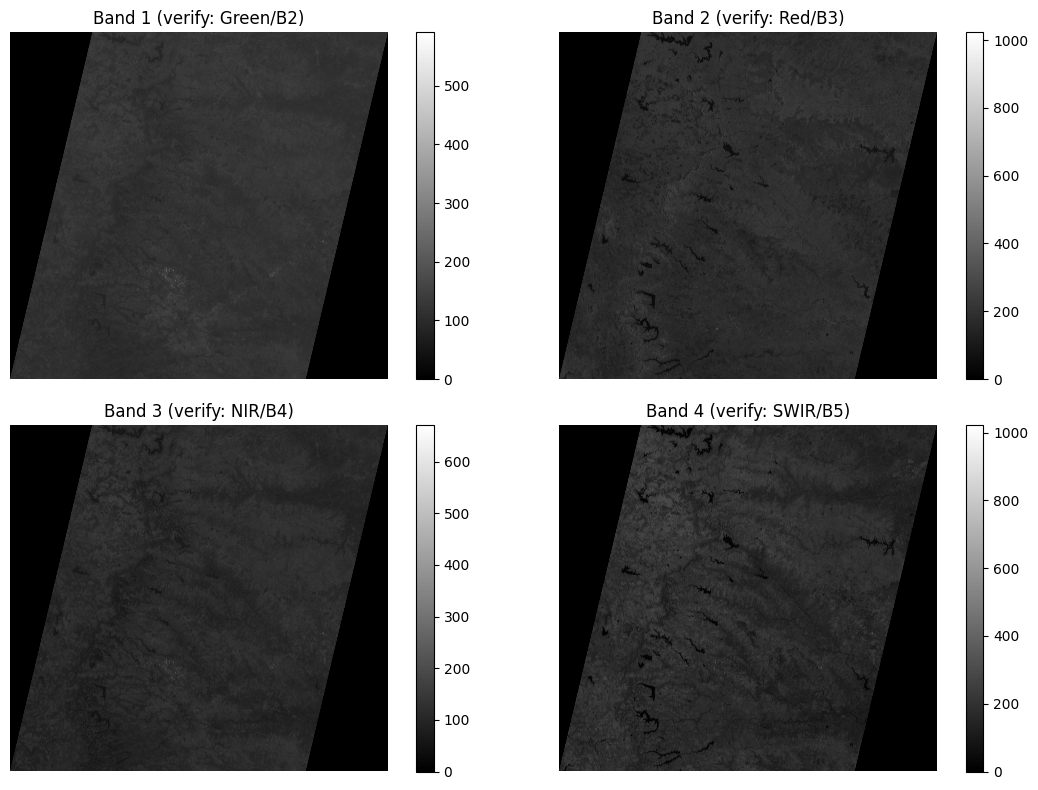

In [ ]:
if len(tif_files) >= 4:
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    names = ["Band 1 (verify: Green/B2)", "Band 2 (verify: Red/B3)",
             "Band 3 (verify: NIR/B4)", "Band 4 (verify: SWIR/B5)"]
    for a, b, name in zip(ax.ravel(), bands, names):
        im = a.imshow(b, cmap="gray")
        a.set_title(name)
        a.axis("off")
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.tight_layout()


In [ ]:

if len(tif_files) >= 4:
    for i,b in enumerate(bands,1):
        print(f"Band {i}: shape={b.shape}, min={np.nanmin(b):.2f}, max={np.nanmax(b):.2f}, mean={np.nanmean(b):.2f}")

Band 1: shape=(7113, 7744), min=0.00, max=591.00, mean=92.77
Band 2: shape=(7113, 7744), min=0.00, max=1023.00, mean=139.82
Band 3: shape=(7113, 7744), min=0.00, max=671.00, mean=85.99
Band 4: shape=(7113, 7744), min=0.00, max=1023.00, mean=136.60


In [ ]:
if len(tif_files) >= 4:
    G, R, NIR, SWIR = bands
    eps = 1e-6
    ndvi = (NIR - R) / (NIR + R + eps)
    rows, cols = np.indices(G.shape)
    sample = pd.DataFrame({
        "row": rows.ravel(),
        "col": cols.ravel(),
        "green": G.ravel(),
        "red": R.ravel(),
        "nir": NIR.ravel(),
        "swir": SWIR.ravel(),
        "ndvi": ndvi.ravel()
    })
    sample = sample.replace([np.inf, -np.inf], np.nan).dropna()
    print(sample.head())
    print("Number of valid pixels:", len(sample))


   row  col  green  red  nir  swir  ndvi
0    0    0    0.0  0.0  0.0   0.0   0.0
1    0    1    0.0  0.0  0.0   0.0   0.0
2    0    2    0.0  0.0  0.0   0.0   0.0
3    0    3    0.0  0.0  0.0   0.0   0.0
4    0    4    0.0  0.0  0.0   0.0   0.0
Number of valid pixels: 55083072


In [ ]:
# Teaching labels. Thresholds are deliberately exposed so students can experiment.
if len(tif_files) >= 4:
    brightness = (G + R + NIR + SWIR) / 4.0

    # These are illustrative rules, not scientific land-cover classification.
    y = np.full(len(sample), -1, dtype=int)
    s_ndvi = sample["ndvi"].to_numpy()
    s_red = sample["red"].to_numpy()
    s_nir = sample["nir"].to_numpy()

    # 0 = water-like, 1 = vegetation-like, 2 = other
    water = (s_ndvi < 0.0) & (s_nir < np.nanpercentile(s_nir, 45))
    veg = (s_ndvi > 0.35)
    other = ~(water | veg)

    y[water] = 0
    y[veg] = 1
    y[other] = 2
    sample["label"] = y

    print(sample["label"].value_counts().sort_index())

label
0    11929042
1           2
2    43154028
Name: count, dtype: int64


In [ ]:
def fit_nearest_centroid(X, y):
    classes = np.unique(y)
    centroids = {}
    for c in classes:
        centroids[c] = X[y == c].mean(axis=0)
    return centroids

def predict_nearest_centroid(X, centroids):
    classes = sorted(centroids.keys())
    C = np.vstack([centroids[c] for c in classes])
    # squared Euclidean distance: samples x classes
    d2 = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    return np.array([classes[i] for i in np.argmin(d2, axis=1)])

features = ["green","red","nir","swir"]
work = sample[sample["label"] >= 0].copy()

# Simple reproducible split
rng = np.random.default_rng(42)
idx = rng.permutation(len(work))
cut = int(0.7 * len(work))
train = work.iloc[idx[:cut]]
test  = work.iloc[idx[cut:]]

# Standardise using training statistics so one band does not dominate by scale.
mu = train[features].mean().to_numpy()
sigma = train[features].std().to_numpy() + 1e-8

X_train = (train[features].to_numpy() - mu) / sigma
X_test  = (test[features].to_numpy() - mu) / sigma

centroids = fit_nearest_centroid(X_train, train["label"].to_numpy())
pred = predict_nearest_centroid(X_test, centroids)

accuracy = np.mean(pred == test["label"].to_numpy())
print("Simple hold-out accuracy:", round(accuracy, 3))
print("Centroids:")
for c,v in centroids.items():
    print(c, np.round(v,2))


NameError: name 'sample' is not defined